# 15f. Real Data — 1nW Trans80 (12d model + Fisher)
## Experiment

Applying the **12d model** (2D KDE likelihood + Fisher information) to real PLE data.

| | |
|---|---|
| Session | 1nW red laser, Trans80 transmission |
| Data file | `data/raw_data/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans80.txt` |
| True μ (`pho_normal_mean`) | 79.365 |
| True σ_phys (`pho_normal_std`) | 12.627 |
| True λ (`pho_noise_poisson_mean`) | 2.758 |
| True γ (median FWHM @ Trans100 / 2) | 8.5 MHz |
| μ init | 39.68 (= 0.5 × true μ) |
| γ init | 8.5 MHz (median FWHM @ Trans100 / 2) |

**Preprocessing:** raw values ×1000 → MHz; drop NaN rows; drop degenerate fits (`err/fwhm ≥ 10`).
**Model:** σ_phys and λ fixed to the experiment's true values; (μ, γ) optimized via the
KDE negative log-likelihood; Fisher information → CRB covariance at the optimum.
**Plot:** found (μ̂, γ̂) with its 1σ/2σ covariance ellipse, the true μ reference, and the
FWHM distribution match.


In [1]:
import math, time, os, sys
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)

for _p in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '..', '..')]:
    if os.path.isdir(os.path.join(_p, 'src')):
        sys.path.insert(0, _p)
        REPO_ROOT = _p
        break
os.chdir(REPO_ROOT)

from src.fitting import (
    _raw_from_width as _rw,
    log_pdf, nll, fwhm_from_theta, fit_profile
)
from src.samplers import draw_fixed_noise, build_photons
from src.implicit import compute_fwhm_and_dgamma

print('Imports OK')

Imports OK


In [2]:
# --- experiment parameters (true values from data_explanation.md) ---
POWER = '1nW'
TRANSMISSION = 'Trans80'
DATA_FILE = 'data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans80.txt'

MU_TRUE = 79.365       # pho_normal_mean
SIGMA_PROP = 12.627   # pho_normal_std   (fixed, true)
LAMBDA_ = 2.758      # pho_noise_poisson_mean (fixed, true)
GAMMA_TRUE = 8.5   # median FWHM @ Trans100 / 2 (reference)
GAMMA_INIT = 0.5 * GAMMA_TRUE   # half the true-γ reference
MU_INIT = 39.682   # 0.5 * MU_TRUE

# --- optimization (as 12d) ---
N_RUNS = 500
N_ITER = 80
LR_MU = 15.0
LR_GAMMA = 0.5
CLIP = 10.0
SEED = 42

# --- fisher block (as 12d) ---
# Step 1: 1 seed (quick/dirty debug) -> 5 seeds (full, as 12d)
M_FINAL = 500
FISHER_SEEDS = 5
FISHER_BASE_SEED = 7000

print('Parameters set')

Parameters set


## Load & preprocess the real data

- raw (FWHM, fit_error) ×1000 → MHz
- drop NaN rows (failed fits)
- drop degenerate fits: `err/fwhm < 10` (safety filter, per data_explanation.md)
- the (FWHM, fit_error) pairs are the 2D target — fit_error plays the role of σ in 12d
- Scott's rule bandwidths computed on the target, fixed for the whole run


rows: 3200 | valid: 2494 | after filter: 2487
target FWHM: 17.3 ± 5.3 MHz
target err:  1.22 ± 3.29 MHz  (median 0.76)
Scott bandwidths: h_f=1.44 MHz, h_s=0.894 MHz


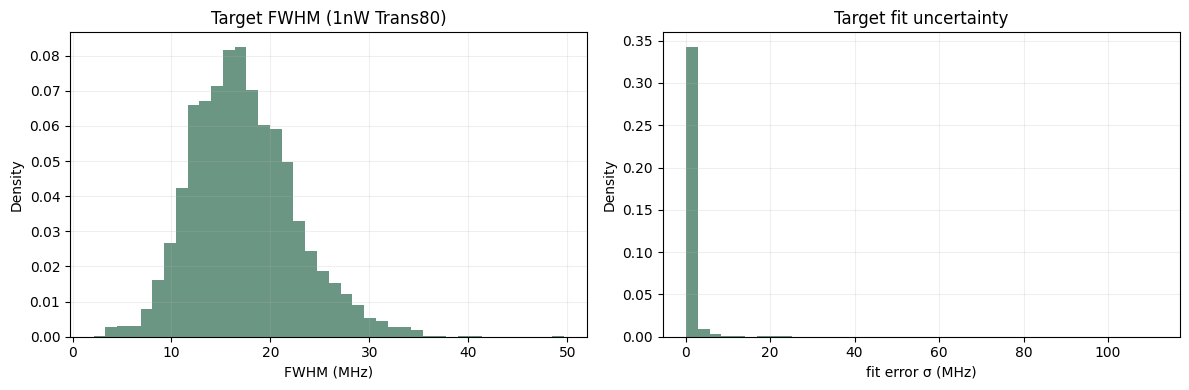

In [3]:
def _fit_fn(ph):
    return fit_profile(ph, n_iters=80, model='lorentzian', uniform_bg=False)

def _fwhm_fn(th):
    return fwhm_from_theta(th, model='lorentzian')

def _nll_fn(th, ph):
    return nll(th, ph, model='lorentzian', uniform_bg=False)

d = np.genfromtxt(DATA_FILE)
fwhm_mhz = d[:, 0] * 1000.0
err_mhz = d[:, 1] * 1000.0
ok = ~np.isnan(fwhm_mhz) & ~np.isnan(err_mhz) & (fwhm_mhz > 0)
filt = ok & (err_mhz / fwhm_mhz < 10.0)

target_f = torch.tensor(fwhm_mhz[filt], dtype=torch.float32)
target_s = torch.tensor(err_mhz[filt], dtype=torch.float32)
N_TARGET = len(target_f)

SCOTT_EXP = N_TARGET ** (-1.0 / 6.0)
H_F = float(target_f.std()) * SCOTT_EXP
H_S = float(target_s.std()) * SCOTT_EXP

print(f"rows: {len(d)} | valid: {ok.sum()} | after filter: {N_TARGET}")
print(f"target FWHM: {target_f.mean():.1f} ± {target_f.std():.1f} MHz")
print(f"target err:  {target_s.mean():.2f} ± {target_s.std():.2f} MHz  (median {torch.median(target_s):.2f})")
print(f"Scott bandwidths: h_f={H_F:.2f} MHz, h_s={H_S:.3f} MHz")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(target_f.numpy(), bins=40, density=True, alpha=0.7, color='#2d6a4f')
ax1.set_xlabel('FWHM (MHz)'); ax1.set_ylabel('Density')
ax1.set_title(f'Target FWHM (1nW Trans80)')
ax1.grid(alpha=0.2)
ax2.hist(target_s.numpy(), bins=40, density=True, alpha=0.7, color='#2d6a4f')
ax2.set_xlabel('fit error σ (MHz)'); ax2.set_ylabel('Density')
ax2.set_title('Target fit uncertainty')
ax2.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## KDE likelihood & gradients (identical to 12d)

```
p̂(f, s; θ) = (1/M) Σᵢ exp(−(f−fᵢ)²/2h_f² − (s−sᵢ)²/2h_s²)
L(θ) = −(1/N) Σ_k log p̂(f_k, s_k; θ)
```
μ gradient: weighted REINFORCE with responsibility baseline · γ gradient: analytic KDE chain.


In [4]:
def kde_scores(sim_f, sim_s, sim_n, sim_df, sim_ds, data_f, data_s, h_f, h_s, mu):
    d_f = data_f[:, None] - sim_f[None, :]
    d_s = data_s[:, None] - sim_s[None, :]
    W = torch.exp(-0.5 * (d_f / h_f) ** 2 - 0.5 * (d_s / h_s) ** 2)
    w = W / W.sum(dim=1, keepdim=True).clamp_min(1e-12)
    score = (sim_n[None, :] - mu) / SIGMA_PROP ** 2
    s_mu = (w * score).sum(dim=1)
    dlogG = (d_f * sim_df[None, :]) / h_f ** 2 + (d_s * sim_ds[None, :]) / h_s ** 2
    s_gamma = (w * dlogG).sum(dim=1)
    logp = torch.log((W.sum(dim=1) / len(sim_f)).clamp_min(1e-30))
    nll_val = -logp.mean()
    return s_mu, s_gamma, nll_val, w


def kde_scores_1d(sim_f, sim_n, sim_df, data_f, h_f, mu):
    d_f = data_f[:, None] - sim_f[None, :]
    W = torch.exp(-0.5 * (d_f / h_f) ** 2)
    w = W / W.sum(dim=1, keepdim=True).clamp_min(1e-12)
    score = (sim_n[None, :] - mu) / SIGMA_PROP ** 2
    s_mu = (w * score).sum(dim=1)
    dlogG = (d_f * sim_df[None, :]) / h_f ** 2
    s_gamma = (w * dlogG).sum(dim=1)
    return s_mu, s_gamma, w

print('KDE likelihood functions ready')

KDE likelihood functions ready


## Joint optimization loop (as 12d)

N_ITER=80 × N_RUNS=500, μ LR 15→4.5, γ LR 0.5, clip ±10. True σ_phys and λ are fixed.


In [5]:
t_total = time.time()
mu_val = float(MU_INIT)
gamma_val = float(GAMMA_INIT)
history = []

print(f"μ_init={MU_INIT:.2f}, γ_init={GAMMA_INIT:.1f} | true μ={MU_TRUE}")
print(f"σ_phys={SIGMA_PROP:.2f} (fixed), λ={LAMBDA_:.2f} (fixed), N_target={N_TARGET}\n")

for step in range(N_ITER):
    rng2 = np.random.default_rng(SEED + step)
    fwhms, sigmas, dfs, dsigmas, ns = [], [], [], [], []

    for _ in range(N_RUNS):
        u, b, n = draw_fixed_noise(mu_val, SIGMA_PROP, LAMBDA_, rng2)
        fw, sig, dg = compute_fwhm_and_dgamma(
            gamma_val, u.numpy(), b.numpy(),
            _fit_fn, _fwhm_fn, _nll_fn, n_params=2
        )
        fwhms.append(fw); sigmas.append(sig); dfs.append(dg)
        dsigmas.append(min(2.0 / math.sqrt(max(int(n), 1)), 2.0))
        ns.append(n)

    ft = torch.tensor(fwhms, dtype=torch.float32)
    si_t = torch.tensor(sigmas, dtype=torch.float32)
    nt = torch.tensor(ns, dtype=torch.float32)
    dg_t = torch.tensor(dfs, dtype=torch.float32)
    ds_t = torch.tensor(dsigmas, dtype=torch.float32)

    s_mu, s_gamma, nll_val, w = kde_scores(
        ft, si_t, nt, dg_t, ds_t,
        target_f, target_s, H_F, H_S, mu_val
    )

    B = w.mean(dim=0)
    score = (nt - mu_val) / SIGMA_PROP ** 2
    grad_mu = float(max(min(-(B - B.mean()) @ score, CLIP), -CLIP))
    grad_gamma = float(max(min(-s_gamma.mean(), CLIP), -CLIP))

    lr_mu_decay = LR_MU * max(0.3, 1.0 - step / N_ITER)
    mu_val -= lr_mu_decay * grad_mu
    mu_val = max(1.0, min(200.0, mu_val))
    gamma_val -= LR_GAMMA * grad_gamma
    gamma_val = max(0.1, min(100.0, gamma_val))

    history.append({
        'step': step, 'mu': mu_val, 'gamma': gamma_val,
        'nll': float(nll_val), 'grad_mu': grad_mu, 'grad_gamma': grad_gamma,
        'mean_n': float(nt.mean()), 'B_max': float(B.max()),
    })

    if step % 5 == 0 or step == N_ITER - 1:
        print(f"  S{step:2d}: μ={mu_val:6.2f} γ={gamma_val:5.2f} | "
              f"NLL={nll_val:7.2f} | ∇μ={grad_mu:+.4f} ∇γ={grad_gamma:+.4f} | "
              f"n̄={float(nt.mean()):5.1f} ({time.time()-t_total:.0f}s)", flush=True)

print(f"\nDone. {time.time()-t_total:.0f}s")

μ_init=39.68, γ_init=4.2 | true μ=79.365
σ_phys=12.63 (fixed), λ=2.76 (fixed), N_target=2487



  S 0: μ= 38.74 γ= 5.25 | NLL=   5.03 | ∇μ=+0.0627 ∇γ=-1.9967 | n̄= 39.6 (9s)


  S 5: μ= 37.45 γ= 6.78 | NLL=   3.12 | ∇μ=+0.0117 ∇γ=-0.4024 | n̄= 37.8 (49s)


  S10: μ= 36.95 γ= 7.37 | NLL=   2.82 | ∇μ=+0.0063 ∇γ=-0.2093 | n̄= 37.4 (90s)


  S15: μ= 36.74 γ= 7.71 | NLL=   2.74 | ∇μ=+0.0032 ∇γ=-0.1246 | n̄= 36.1 (131s)


...

  S65: μ= 36.21 γ= 8.01 | NLL=   2.76 | ∇μ=+0.0003 ∇γ=+0.0107 | n̄= 35.1 (551s)


  S70: μ= 36.19 γ= 8.03 | NLL=   2.91 | ∇μ=+0.0017 ∇γ=-0.0173 | n̄= 36.6 (594s)


  S75: μ= 36.18 γ= 8.00 | NLL=   2.68 | ∇μ=+0.0035 ∇γ=+0.0149 | n̄= 36.1 (636s)


  S79: μ= 36.15 γ= 8.00 | NLL=   2.91 | ∇μ=+0.0006 ∇γ=+0.0649 | n̄= 37.7 (670s)



Done. 670s


In [6]:
if len(history) > 0:
    fmu = history[-1]['mu']
    fga = history[-1]['gamma']
    print(f"{'='*70}")
    print(f"  REAL DATA — {POWER} {TRANSMISSION}: 2D KDE LIKELIHOOD + FISHER")
    print(f"{'='*70}")
    print(f"  μ:     {MU_INIT:.2f} → {fmu:.2f}   (true {MU_TRUE})  error={abs(fmu-MU_TRUE):.2f}")
    print(f"  γ:     {GAMMA_INIT:.1f} → {fga:.2f}  MHz   (true γ {GAMMA_TRUE})")
    print(f"  NLL:   {history[0]['nll']:.2f} → {history[-1]['nll']:.2f}")
    print(f"  Time:  {time.time()-t_total:.0f}s")
    print(f"{'='*70}")

  REAL DATA — 1nW Trans80: 2D KDE LIKELIHOOD + FISHER
  μ:     39.68 → 36.15   (true 79.365)  error=43.21
  γ:     4.2 → 8.00  MHz   (true γ 8.5)
  NLL:   5.03 → 2.91
  Time:  670s


## Fisher information & Cramér–Rao bound (as 12d)

Fresh high-M simulation at the optimum → per-data-point scores → J = (1/N)Σ s sᵀ →
Cov = J⁻¹ → CRB standard errors, correlation, confidence ellipse. Plus the 1D
FWHM-only Fisher as the degeneracy diagnostic.


In [7]:
mu_final = history[-1]['mu']
gamma_final = history[-1]['gamma']

J_list, J1_list = [], []

for seed in range(FISHER_SEEDS):
    rng = np.random.default_rng(FISHER_BASE_SEED + seed)
    fwhms, sigmas, dfs, dsigmas, ns = [], [], [], [], []
    for _ in range(M_FINAL):
        u, b, n = draw_fixed_noise(mu_final, SIGMA_PROP, LAMBDA_, rng)
        fw, sig, dg = compute_fwhm_and_dgamma(
            gamma_final, u.numpy(), b.numpy(),
            _fit_fn, _fwhm_fn, _nll_fn, n_params=2)
        fwhms.append(fw); sigmas.append(sig); dfs.append(dg)
        dsigmas.append(min(2.0 / math.sqrt(max(int(n), 1)), 2.0))
        ns.append(n)

    ft = torch.tensor(fwhms, dtype=torch.float32)
    si_t = torch.tensor(sigmas, dtype=torch.float32)
    nt = torch.tensor(ns, dtype=torch.float32)
    dg_t = torch.tensor(dfs, dtype=torch.float32)
    ds_t = torch.tensor(dsigmas, dtype=torch.float32)

    s_mu, s_gamma, _, _ = kde_scores(ft, si_t, nt, dg_t, ds_t,
                                     target_f, target_s, H_F, H_S, mu_final)
    s = torch.stack([s_mu, s_gamma], dim=1)
    J_list.append(s.T @ s / len(target_f))

    s_mu_1, s_gamma_1, _ = kde_scores_1d(ft, nt, dg_t, target_f, H_F, mu_final)
    s1 = torch.stack([s_mu_1, s_gamma_1], dim=1)
    J1_list.append(s1.T @ s1 / len(target_f))

J = torch.stack(J_list).mean(dim=0)
J_std = torch.stack(J_list).std(dim=0)
J1 = torch.stack(J1_list).mean(dim=0)

Jinv = torch.linalg.inv(J + 1e-8 * torch.eye(2))
std_mu = math.sqrt(Jinv[0, 0])
std_gamma = math.sqrt(Jinv[1, 1])
corr = Jinv[0, 1] / math.sqrt(Jinv[0, 0] * Jinv[1, 1])
eigs = torch.linalg.eigvalsh(J)
eigs_1d = torch.linalg.eigvalsh(J1)

print(f"=== FISHER at (μ̂, γ̂) = ({mu_final:.2f}, {gamma_final:.2f}) — {POWER} {TRANSMISSION} ===")
print(f"  J = [[{J[0,0]:9.4f}, {J[0,1]:9.4f}]")
print(f"       [{J[1,0]:9.4f}, {J[1,1]:9.4f}]]")
print(f"  J spread: {J_std[0,0]:.4f} (μμ), {J_std[1,1]:.4f} (γγ)")
print(f"  CRB std: σ_μ = {std_mu:.2f}   σ_γ = {std_gamma:.2f}   corr = {corr:+.2f}")
print(f"  Eigenvalues 2D: {eigs[0]:.4f}, {eigs[1]:.4f} (ratio {eigs[1]/eigs[0]:.1f})")
print(f"  Eigenvalues 1D: {eigs_1d[0]:.4f}, {eigs_1d[1]:.4f} (ratio {eigs_1d[1]/eigs_1d[0]:.1f})")
print(f"  μ̂ vs μ_true: {mu_final:.2f} vs {MU_TRUE}  (Δ = {mu_final-MU_TRUE:+.2f}, "
      f"{abs(mu_final-MU_TRUE)/std_mu:.2f}σ)")

=== FISHER at (μ̂, γ̂) = (36.15, 8.00) — 1nW Trans80 ===
  J = [[   0.0013,   -0.0080]
       [  -0.0080,    0.5660]]
  J spread: 0.0002 (μμ), 0.1542 (γγ)
  CRB std: σ_μ = 29.17   σ_γ = 1.39   corr = +0.30
  Eigenvalues 2D: 0.0012, 0.5661 (ratio 481.8)
  Eigenvalues 1D: 0.0005, 0.2545 (ratio 511.0)
  μ̂ vs μ_true: 36.15 vs 79.365  (Δ = -43.21, 1.48σ)


## Visualization

Optimization trajectory with the CRB ellipse (1σ, 2σ) around the final point,
the true μ as a reference line, and the FWHM distribution match.


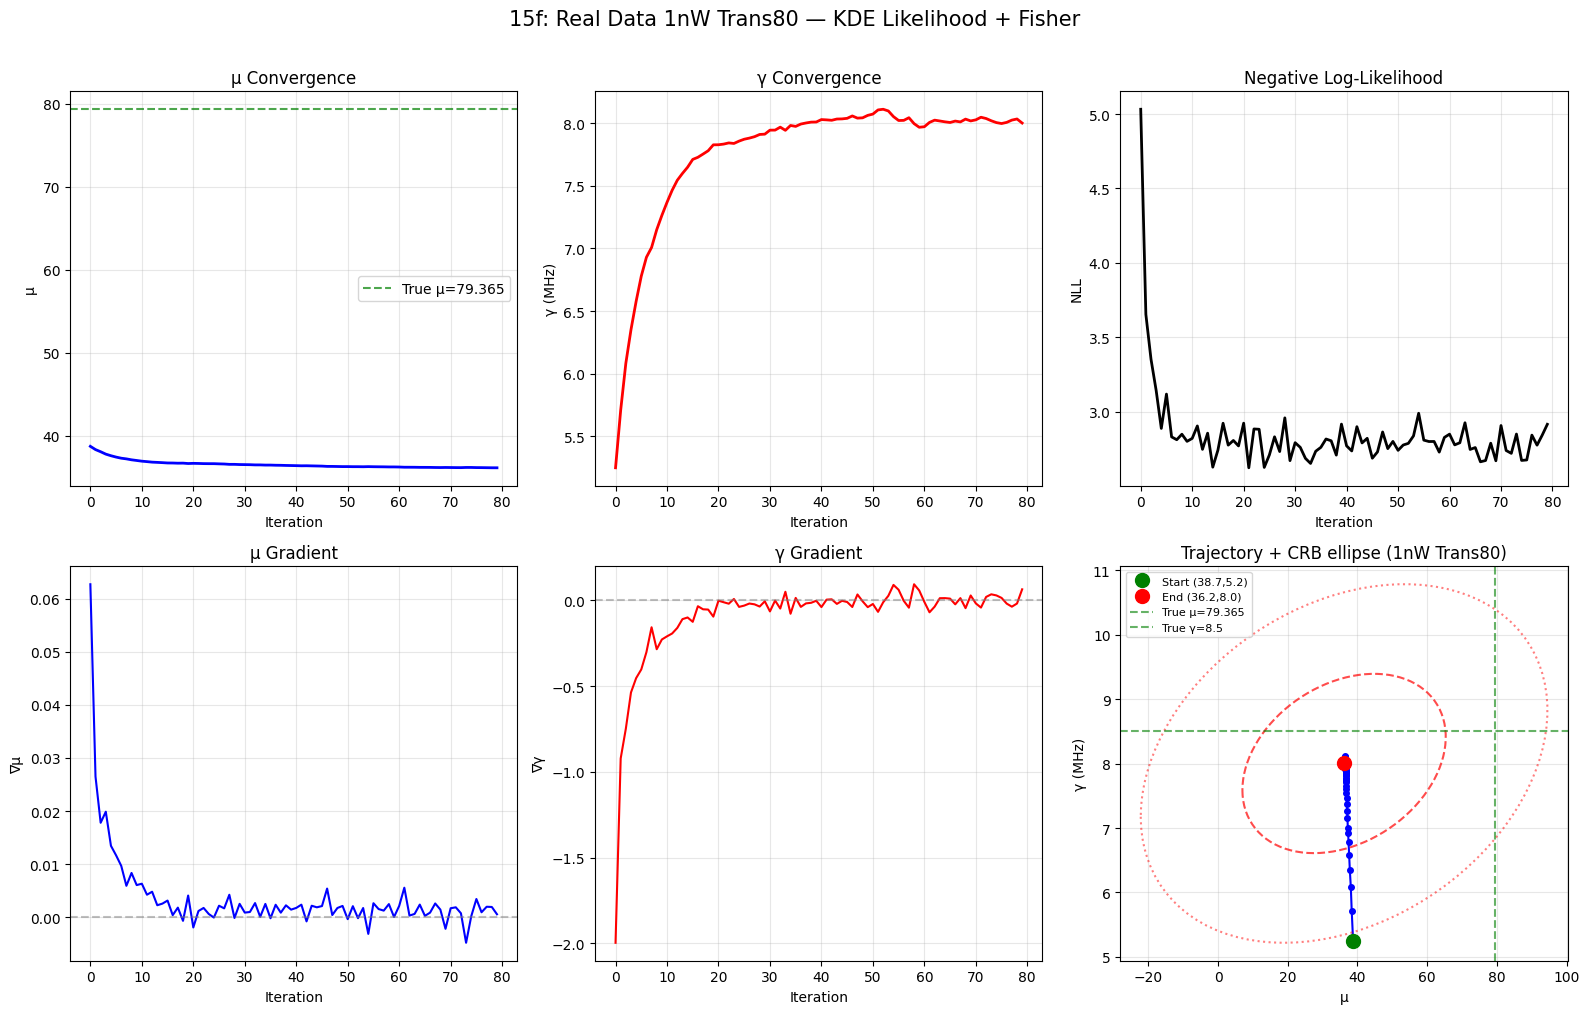

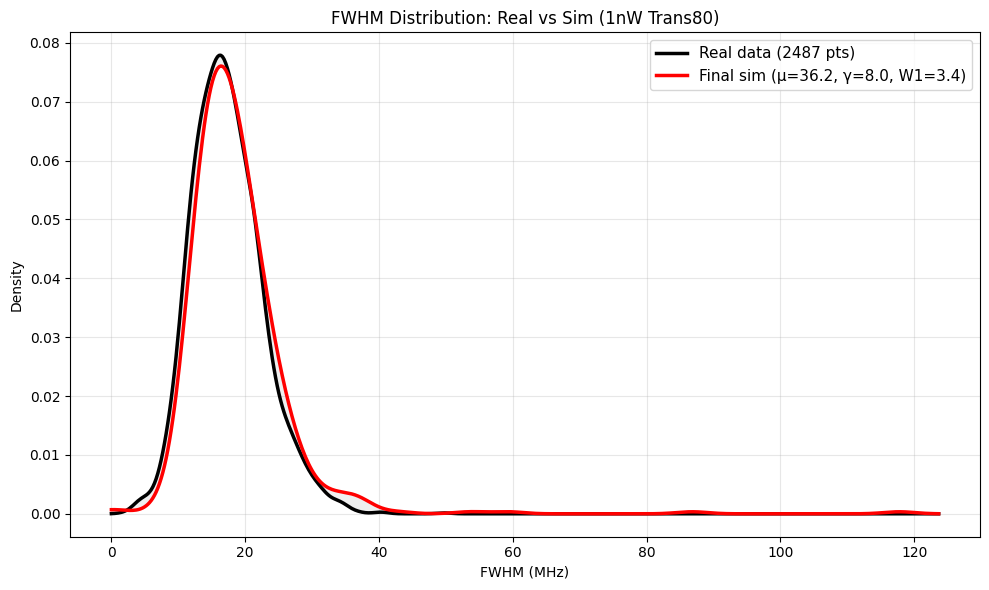

Real FWHM: 17.3 ± 5.3 MHz
Final sim: 18.8 ± 8.0 MHz
Recovered: μ = 36.15 (true 79.365, Δ=-43.21, 1.48σ) | γ = 8.00 MHz (σ_γ=1.39)


In [8]:
from scipy.stats import gaussian_kde
from src.losses import wasserstein_loss

steps = [h['step'] for h in history]
mu_hist = [h['mu'] for h in history]
gamma_hist = [h['gamma'] for h in history]

# fresh forward pass at the recovered parameters
rng_f = np.random.default_rng(999)
final_fwhms = []
for _ in range(500):
    u, b, n = draw_fixed_noise(mu_hist[-1], SIGMA_PROP, LAMBDA_, rng_f)
    photons = build_photons(torch.tensor(gamma_hist[-1], dtype=torch.float32), u, b)
    theta = fit_profile(photons, n_iters=80, model='lorentzian', uniform_bg=False)
    if theta is not None:
        final_fwhms.append(fwhm_from_theta(theta, model='lorentzian').item())
    else:
        final_fwhms.append(2.0 * gamma_hist[-1])
final_t = torch.tensor(final_fwhms, dtype=torch.float32)
w1_final = wasserstein_loss(final_t, target_f).item()

def cov_to_ellipse(cov2, level=1.0):
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    theta = np.linspace(0, 2 * np.pi, 100)
    xy = np.vstack([level * np.sqrt(eigvals[0]) * np.cos(theta),
                    level * np.sqrt(eigvals[1]) * np.sin(theta)])
    return eigvecs @ xy

Jinv_np = Jinv.numpy()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

ax = axes[0, 0]
ax.axhline(MU_TRUE, color='g', ls='--', linewidth=1.5, alpha=0.7, label=f'True μ={MU_TRUE}')
ax.plot(steps, mu_hist, 'b-', linewidth=2)
ax.set_xlabel('Iteration'); ax.set_ylabel('μ')
ax.set_title('μ Convergence'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(steps, gamma_hist, 'r-', linewidth=2)
ax.set_xlabel('Iteration'); ax.set_ylabel('γ (MHz)')
ax.set_title('γ Convergence'); ax.grid(alpha=0.3)

ax = axes[0, 2]
ax.plot(steps, [h['nll'] for h in history], 'k-', linewidth=2)
ax.set_xlabel('Iteration'); ax.set_ylabel('NLL')
ax.set_title('Negative Log-Likelihood'); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(steps, [h['grad_mu'] for h in history], 'b-', linewidth=1.5)
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Iteration'); ax.set_ylabel('∇μ')
ax.set_title('μ Gradient'); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(steps, [h['grad_gamma'] for h in history], 'r-', linewidth=1.5)
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Iteration'); ax.set_ylabel('∇γ')
ax.set_title('γ Gradient'); ax.grid(alpha=0.3)

ax = axes[1, 2]
ax.plot(mu_hist, gamma_hist, 'b.-', linewidth=1.5, markersize=8)
ax.plot(mu_hist[0], gamma_hist[0], 'go', markersize=10, label=f'Start ({mu_hist[0]:.1f},{gamma_hist[0]:.1f})')
ax.plot(mu_hist[-1], gamma_hist[-1], 'ro', markersize=10, label=f'End ({mu_hist[-1]:.1f},{gamma_hist[-1]:.1f})')
xy1 = cov_to_ellipse(Jinv_np, level=1.0)
xy2 = cov_to_ellipse(Jinv_np, level=2.0)
ax.plot(xy1[0] + mu_hist[-1], xy1[1] + gamma_hist[-1], 'r--', alpha=0.7, linewidth=1.5)
ax.plot(xy2[0] + mu_hist[-1], xy2[1] + gamma_hist[-1], 'r:', alpha=0.5, linewidth=1.5)
ax.axvline(MU_TRUE, color='g', ls='--', alpha=0.6, label=f'True μ={MU_TRUE}')
ax.axhline(GAMMA_TRUE, color='g', ls='--', alpha=0.6, label=f'True γ={GAMMA_TRUE}')
ax.set_xlabel('μ'); ax.set_ylabel('γ (MHz)')
ax.set_title('Trajectory + CRB ellipse (1nW Trans80)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('15f: Real Data 1nW Trans80 — KDE Likelihood + Fisher', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(f'fig_15_1nWTrans80.png', dpi=150, bbox_inches='tight')
plt.show()

x_grid = np.linspace(0, max(target_f.max(), final_t.max()).item() * 1.05, 500)
kde_target = gaussian_kde(target_f.numpy())
kde_final = gaussian_kde(final_t.numpy())
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_grid, kde_target(x_grid), 'k-', linewidth=2.5, label=f'Real data ({len(target_f)} pts)')
ax.plot(x_grid, kde_final(x_grid), 'r-', linewidth=2.5, label=f'Final sim (μ={mu_hist[-1]:.1f}, γ={gamma_hist[-1]:.1f}, W1={w1_final:.1f})')
ax.fill_between(x_grid, kde_final(x_grid), kde_target(x_grid), alpha=0.12, color='gray')
ax.set_xlabel('FWHM (MHz)'); ax.set_ylabel('Density')
ax.set_title('FWHM Distribution: Real vs Sim (1nW Trans80)')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'fig_15_1nWTrans80_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Real FWHM: {target_f.mean():.1f} ± {target_f.std():.1f} MHz')
print(f'Final sim: {final_t.mean():.1f} ± {final_t.std():.1f} MHz')
print(f'Recovered: μ = {mu_hist[-1]:.2f} (true {MU_TRUE}, Δ={mu_hist[-1]-MU_TRUE:+.2f}, {abs(mu_hist[-1]-MU_TRUE)/std_mu:.2f}σ) | '
      f'γ = {gamma_hist[-1]:.2f} MHz (σ_γ={std_gamma:.2f})')